In [11]:
import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md

In [12]:
# Load trajectory
pdb = md.load('/home/tedeschg/prj/cvformer/cvformer-test/test02/2JOF-0-proteinNoH.pdb')
traj = md.load('/home/tedeschg/prj/cvformer/cvformer-test/test02/traj_skip100NoH.xtc', top=pdb)
cvs = np.load('/home/tedeschg/prj/cvformer/cvformer-test/test05/output/latents.npy')

cv1, cv2 = cvs[:,0], cvs[:,1]


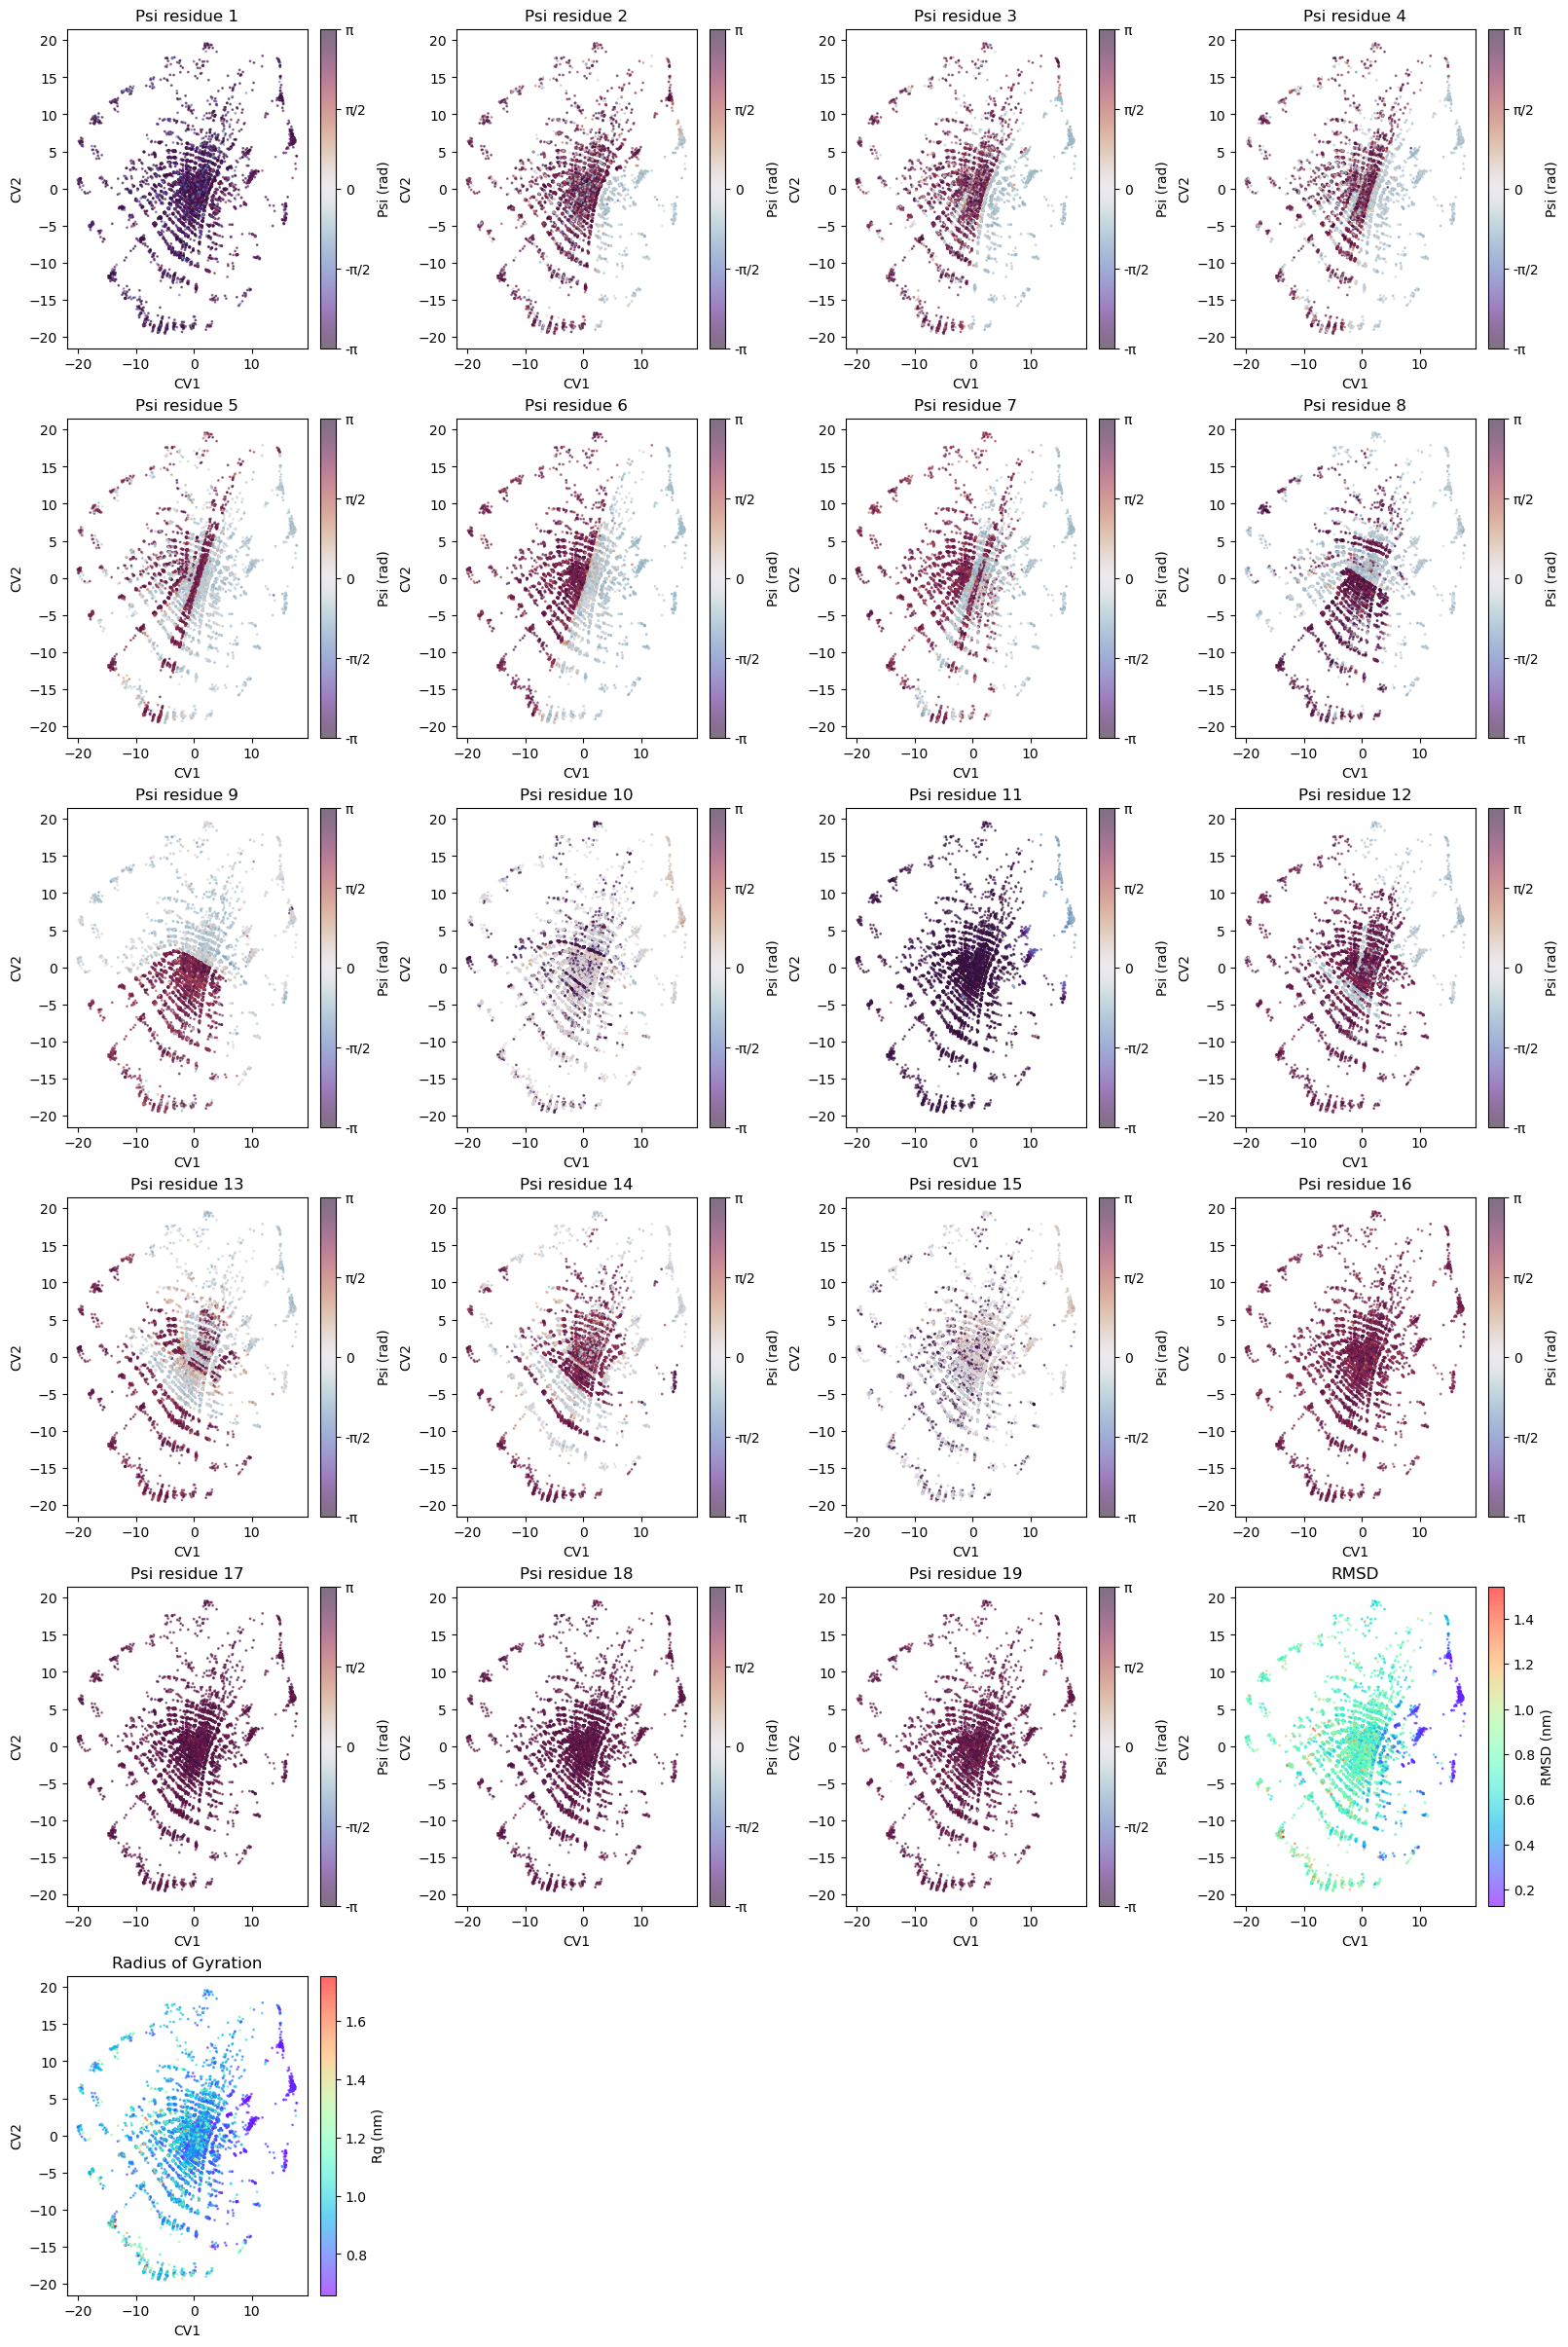

In [13]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Reset completo (evita che restino stili "dark" attivi)
mpl.rcdefaults()
plt.style.use("default")

# Forza background bianco + testi neri
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})

# --- Calcoli ---
_, phi = md.compute_phi(traj)
_, psi = md.compute_psi(traj)

rmsd = md.rmsd(traj, pdb, 0)
rg   = md.compute_rg(traj)

cv1 = cvs[:, 0]
cv2 = cvs[:, 1]

n_psi = psi.shape[1]

# --- Layout subplot ---
n_plots = n_psi + 2
n_cols = 4
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(16, 4 * n_rows),
    constrained_layout=True
)

# axes può essere 2D → lo "flatteno"
axes = np.array(axes).ravel()

# --- Plot psi ---
for i in range(n_psi):
    ax = axes[i]
    sc = ax.scatter(
        cv1, cv2,
        c=psi[:, i],
        cmap="twilight_shifted",
        s=1, alpha=0.6,
        vmin=-np.pi, vmax=np.pi
    )
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Psi (rad)")
    cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
    cbar.set_ticklabels(["-π", "-π/2", "0", "π/2", "π"])

    ax.set_xlabel("CV1")
    ax.set_ylabel("CV2")
    ax.set_title(f"Psi residue {i + 1}")

# --- RMSD ---
ax = axes[n_psi]
sc = ax.scatter(cv1, cv2, c=rmsd, cmap="rainbow", s=1, alpha=0.6)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("RMSD (nm)")
ax.set_xlabel("CV1")
ax.set_ylabel("CV2")
ax.set_title("RMSD")

# --- Rg ---
ax = axes[n_psi + 1]
sc = ax.scatter(cv1, cv2, c=rg, cmap="rainbow", s=1, alpha=0.6)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Rg (nm)")
ax.set_xlabel("CV1")
ax.set_ylabel("CV2")
ax.set_title("Radius of Gyration")

# --- Spegni gli assi "vuoti" (se la griglia è più grande del numero di plot) ---
for j in range(n_plots, n_rows * n_cols):
    axes[j].axis("off")

# --- Salvataggio ---
fig.savefig("cv_analysis-by-psi.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()



In [14]:
h = np.loadtxt('/home/tedeschg/prj/cvformer/cvformer-test/test04/04.mtd_test-04_plain_cvformer/HILLS')


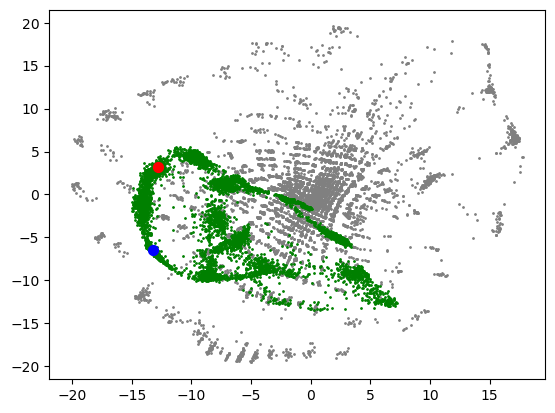

In [15]:
plt.scatter(cv1,cv2, s=1, c='grey')
plt.scatter(h[:, 1], h[:, 2], s=1, c='green', )

plt.scatter(h[-1, 1], h[-1, 2], s=50, c='red')
plt.scatter(h[0, 1], h[0, 2], s=50, c='blue')


In [16]:
import mdtraj as md

traj = md.load("/home/tedeschg/prj/cvformer/cvformer-test/test04/04.mtd_test-04_plain_cvformer/mtd_fit.xtc", top="/home/tedeschg/prj/cvformer/cvformer-test/test04/npt.pdb")


import nglview as nv

view = nv.show_mdtraj(traj)
view



NGLWidget(max_frame=2000)